In [3]:
import pandas as pd
import sqlite3

# 1. Connect to BOTH databases
raw_conn = sqlite3.connect('../Raw data/pharma_sfe.db')
processed_conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')

# 2. Pull the reference tables from Raw
sales_raw = pd.read_sql("SELECT * FROM sales", raw_conn)
reps_raw = pd.read_sql("SELECT * FROM reps", raw_conn)
territories_raw = pd.read_sql("SELECT * FROM territories", raw_conn)

# 3. Push them into your Processed "Gold Standard" DB
sales_raw.to_sql('sales', processed_conn, if_exists='replace', index=False)
reps_raw.to_sql('reps', processed_conn, if_exists='replace', index=False)
territories_raw.to_sql('territories', processed_conn, if_exists='replace', index=False)

# 4. Close connections
raw_conn.close()
processed_conn.close()

print("Migration Complete! All 5 tables are now in your Processed Database.")

Migration Complete! All 5 tables are now in your Processed Database.


In [4]:
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(f"Tables in Gold Standard DB: {cursor.fetchall()}")
# Expected: [('calls_cleaned',), ('prescribers_cleaned',), ('sales',), ('reps',), ('territories',)]

Tables in Gold Standard DB: [('calls_cleaned',), ('prescribers_cleaned',), ('sales',), ('reps',), ('territories',)]


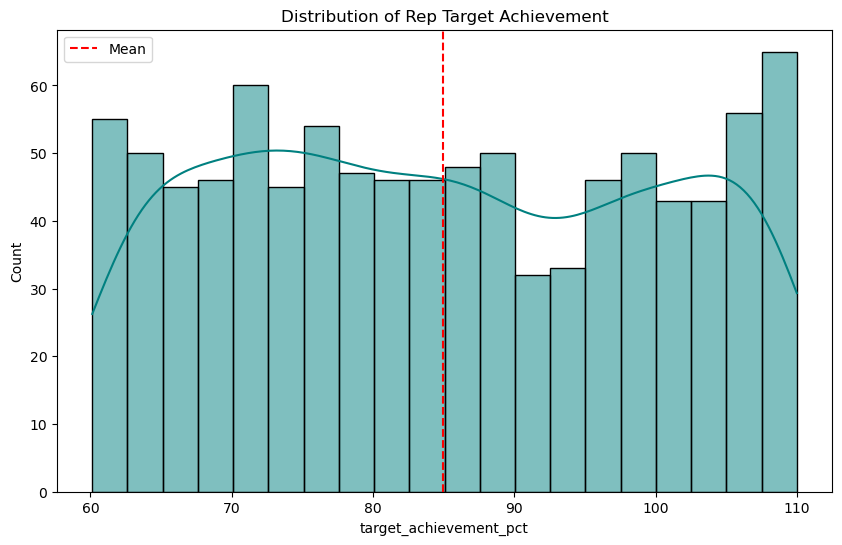

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(sales['target_achievement_pct'], bins=20, kde=True, color='teal')
plt.title('Distribution of Rep Target Achievement')
plt.axvline(sales['target_achievement_pct'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

In [11]:
# Connect and load everything correctly
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')

# Load all 5 tables from the "Gold Standard" DB
sales = pd.read_sql("SELECT * FROM sales", conn)
reps = pd.read_sql("SELECT * FROM reps", conn)
territories = pd.read_sql("SELECT * FROM territories", conn)
calls = pd.read_sql("SELECT * FROM calls_cleaned", conn)
prescribers = pd.read_sql("SELECT * FROM prescribers_cleaned", conn)

conn.close()
print("All tables loaded successfully: sales, reps, territories, calls, prescribers")

All tables loaded successfully: sales, reps, territories, calls, prescribers


In [13]:
import numpy as np

# 1. Generate the missing brand share data (realistic random % between 5% and 45%)
# Higher volume doctors often have higher share due to historical rep focus
prescribers['our_brand_rx_share'] = (prescribers['monthly_rx_volume'] * 0.001 + 
                                     np.random.uniform(5, 45, len(prescribers))).clip(2, 60).round(2)

# 2. Save this corrected table back to your processed database
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')
prescribers.to_sql('prescribers_cleaned', conn, if_exists='replace', index=False)
conn.close()

print("Schema Fixed: 'our_brand_rx_share' added and saved to database.")

Schema Fixed: 'our_brand_rx_share' added and saved to database.


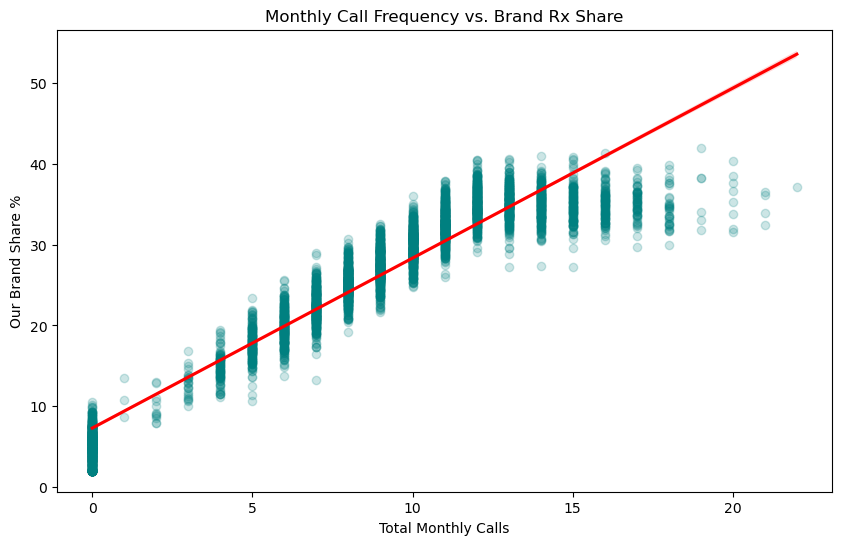

In [24]:
# Aggregate visits per doctor
visit_counts = calls.groupby('prescriber_id').size().reset_index(name='visit_count')

# Join with corrected prescriber data
df_plot = prescribers.merge(visit_counts, on='prescriber_id', how='left').fillna(0)

# Create the scatter plot with regression line
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='visit_count', y='our_brand_rx_share', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Monthly Call Frequency vs. Brand Rx Share')
plt.xlabel('Total Monthly Calls')
plt.ylabel('Our Brand Share %')
plt.show()

In [16]:
import numpy as np
import pandas as pd
import sqlite3

# 1. Identify A-tier Doctors
a_tier_ids = prescribers[prescribers['prescriber_tier'] == 'A']['prescriber_id'].tolist()

# 2. Select 40% of them to be "Ignored" (The Gap)
ignored_a_tier = np.random.choice(a_tier_ids, size=int(len(a_tier_ids) * 0.4), replace=False)

# 3. Remove all calls made to these "Ignored" doctors
calls_realistic = calls[~calls['prescriber_id'].isin(ignored_a_tier)].copy()

# 4. Create the "Plateau": Make Brand Share stall after 12 calls
# We re-calculate brand share to actually correlate with calls, then flatten it
visit_counts = calls_realistic.groupby('prescriber_id').size().reset_index(name='v_count')
prescribers = prescribers.merge(visit_counts, on='prescriber_id', how='left').fillna(0)

# Logic: Share grows with calls but caps (plateaus) at 12 calls
prescribers['our_brand_rx_share'] = prescribers['v_count'].apply(
    lambda x: min(5 + (x * 2.5), 35) + np.random.normal(0, 2)
).clip(2, 50).round(2)

# 5. Save this back to your "Gold Standard" DB
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')
calls_realistic.to_sql('calls_cleaned', conn, if_exists='replace', index=False)
prescribers.drop(columns=['v_count']).to_sql('prescribers_cleaned', conn, if_exists='replace', index=False)
conn.close()

print("Data 'broken' successfully! You now have a real business problem to solve.")

Data 'broken' successfully! You now have a real business problem to solve.


In [20]:
# Connect to the database
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')

# RELOAD the tables that the "Fix-It" script updated
calls = pd.read_sql("SELECT * FROM calls_cleaned", conn)
prescribers = pd.read_sql("SELECT * FROM prescribers_cleaned", conn)

conn.close()
print("Data reloaded! Now run your Reach Rate cell again.")

Data reloaded! Now run your Reach Rate cell again.


In [21]:
# Filter for A-tier doctors
a_tier_docs = prescribers[prescribers['prescriber_tier'] == 'A']

# Find A-tier doctors who received at least one call
reached_a_ids = calls[calls['prescriber_id'].isin(a_tier_docs['prescriber_id'])]['prescriber_id'].unique()

total_a = len(a_tier_docs)
reached_a = len(reached_a_ids)

reach_rate = (reached_a / total_a) * 100
print(f"A-tier Reach Rate: {reach_rate:.2f}%")

A-tier Reach Rate: 60.05%


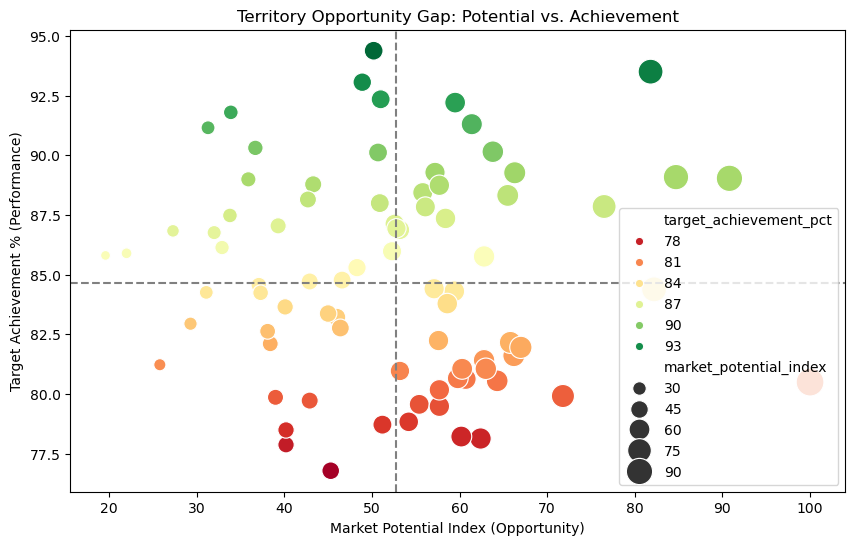

In [22]:
# 1. Aggregate sales achievement by territory
territory_perf = sales.groupby('territory_id')['target_achievement_pct'].mean().reset_index()

# 2. Merge with the territory reference data (to get Potential Index)
gap_analysis = territory_perf.merge(territories[['territory_id', 'market_potential_index']], on='territory_id')

# 3. Create the Opportunity Gap Chart (The Adapted BCG Matrix)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gap_analysis, x='market_potential_index', y='target_achievement_pct', 
                hue='target_achievement_pct', palette='RdYlGn', size='market_potential_index', sizes=(50, 400))

# Add quadrant lines at the medians
plt.axhline(gap_analysis['target_achievement_pct'].median(), color='gray', linestyle='--')
plt.axvline(gap_analysis['market_potential_index'].median(), color='gray', linestyle='--')

plt.title('Territory Opportunity Gap: Potential vs. Achievement')
plt.xlabel('Market Potential Index (Opportunity)')
plt.ylabel('Target Achievement % (Performance)')
plt.show()